<a href="https://colab.research.google.com/github/Ajaymani9345/Movie-Recommendation-System/blob/main/movie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving movies.csv to movies.csv
Saving ratings.csv to ratings.csv


In [24]:
print(movies.columns)
print(ratings.columns)

Index(['index', 'budget', 'genres', 'homepage', 'id', 'keywords',
       'original_language', 'original_title', 'overview', 'popularity',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'vote_average', 'vote_count', 'cast', 'crew', 'director'],
      dtype='object')
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')


In [25]:
movies.rename(columns={'movie_id': 'movieId'}, inplace=True)
ratings.rename(columns={'movie_id': 'movieId'}, inplace=True)

In [26]:
movies.columns = movies.columns.str.strip()
ratings.columns = ratings.columns.str.strip()

In [27]:

movies.columns = movies.columns.str.strip()
ratings.columns = ratings.columns.str.strip()
movie_data = pd.merge(ratings, movies, left_on='movieId', right_on='id')
print(movie_data.head())

   userId  movieId  rating  timestamp  index     budget  \
0       1       70     3.0  964982400   1557   30000000   
1       1      157     5.0  964984100   2317   18000000   
2       1      163     5.0  964983650    247  110000000   
3       1      223     3.0  964980985   4281    1288000   
4       1      231     5.0  964981179    940   50000000   

                                      genres  \
0                                      Drama   
1  Science Fiction Action Adventure Thriller   
2                             Thriller Crime   
3                              Drama Mystery   
4                             Drama Thriller   

                                   homepage   id  \
0  http://www.milliondollarbaby-derfilm.de/   70   
1                                       NaN  157   
2           http://oceans12.warnerbros.com/  163   
3                                       NaN  223   
4       http://syrianamovie.warnerbros.com/  231   

                                           

In [28]:
user_movie_matrix = movie_data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
).fillna(0)

In [29]:
similarity = cosine_similarity(user_movie_matrix)

similarity_df = pd.DataFrame(
    similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

In [30]:
def get_movie_recommendations(movie_name, top_n=5):
    if movie_name not in user_movie_matrix.columns:
        return "Movie not found!", None
    users = user_movie_matrix[user_movie_matrix[movie_name] > 0].index
    if len(users) == 0:
        return "No ratings for this movie!", None
    user = users[0]
    similar_users = similarity_df[user].sort_values(ascending=False)[1:11]
    top_users = similar_users.index
    avg_ratings = user_movie_matrix.loc[top_users].mean().sort_values(ascending=False)
    recommendations = avg_ratings.drop(movie_name).head(top_n)
    return "Top Recommendations:", recommendations

In [31]:
movie_input = input("Enter a movie name: ")
msg, recs = get_movie_recommendations(movie_input)
print(msg)
print(recs)

Enter a movie name: Forrest Gump
Top Recommendations:
title
Monsoon Wedding          4.5
Big Fish                 4.2
Psycho                   4.0
To Kill a Mockingbird    4.0
Romeo + Juliet           3.9
dtype: float64


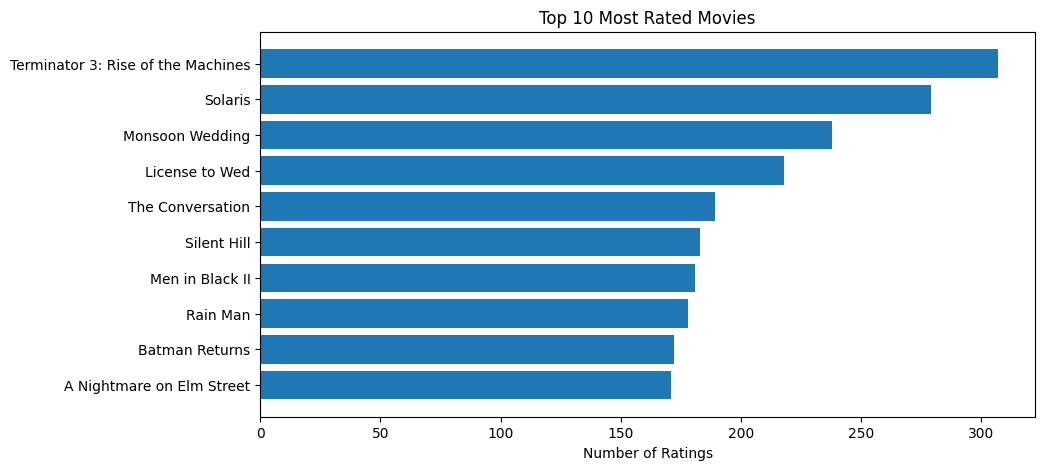

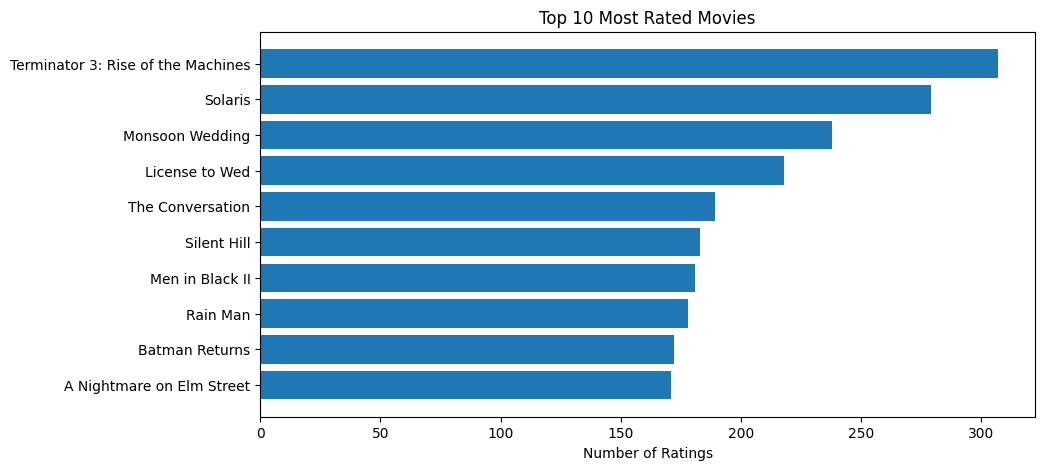

In [32]:
top_movies = movie_data.groupby('title').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(top_movies.index, top_movies.values)
plt.xlabel("Number of Ratings")
plt.title("Top 10 Most Rated Movies")
plt.gca().invert_yaxis()
plt.show()

In [33]:
import difflib

def find_closest_movie(movie_name):
    movie_list = user_movie_matrix.columns.tolist()
    match = difflib.get_close_matches(movie_name, movie_list, n=1, cutoff=0.5)
    return match[0] if match else None

In [34]:
def get_movie_recommendations(movie_name, top_n=5):

    # Find closest matching movie
    movie_name_corrected = find_closest_movie(movie_name)

    if not movie_name_corrected:
        return "Movie not found!", None

    # Users who rated this movie
    users = user_movie_matrix[user_movie_matrix[movie_name_corrected] > 0].index

    if len(users) == 0:
        return "No ratings found!", None

    user = users[0]

    similar_users = similarity_df[user].sort_values(ascending=False)[1:11]
    top_users = similar_users.index

    avg_ratings = user_movie_matrix.loc[top_users].mean().sort_values(ascending=False)

    recommendations = avg_ratings.drop(movie_name_corrected).head(top_n)

    recommendations = recommendations.reset_index()
    recommendations.columns = ['Movie', 'Predicted Rating']

    return f"Showing results for: {movie_name_corrected}", recommendations

In [35]:
def plot_top_rated_movies():
    top_movies = movie_data.groupby('title').size().reset_index(name='rating_count')
    top10 = top_movies.sort_values('rating_count', ascending=False).head(10)

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10,5))
    ax.barh(top10['title'], top10['rating_count'])
    ax.set_xlabel("Number of Ratings")
    ax.set_title("Top 10 Most Rated Movies")
    ax.invert_yaxis()

    return fig

In [36]:
import gradio as gr

def recommend_and_plot(movie_input):
    msg, table = get_movie_recommendations(movie_input)
    fig = plot_top_rated_movies()
    return msg, table, fig

gr.Interface(
    fn=recommend_and_plot,
    inputs=gr.Textbox(label="Enter a Movie You Like"),
    outputs=[
        gr.Textbox(label="Status"),
        gr.Dataframe(label="Recommended Movies"),
        gr.Plot(label="Top 10 Most Rated Movies")
    ],
    title="🎬 Movie Recommender System (Collaborative Filtering)",
    description="Enter a movie name and get recommendations based on similar users' preferences."
).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8bb7ff9bc9ad1e250e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
